**Importing**

In [1]:
from util import *
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

**Compare with part A**

In [2]:
np.random.seed(2025)
state_OLS = np.random.get_state()
n_points = 50

noise = 0.01 * np.random.randn(n_points,1)
x = np.linspace(-1, 1, n_points).reshape(-1,1)
y = Runge(x) + noise

maxdegree = 15
learning_rate = 0.05

mses = []
mses_test = []
r2s = []
r2s_test = []
degrees = []
betas = []

for degree in range(2, maxdegree+1):
    X = PolynomialFeatures(degree).fit_transform(x)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25)

    #Scaling
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)
    y_offset = np.mean(y_train)

    # OLS with gradient descent
    beta = gradient_descent(X_train_s, y_train, OLS_Gradient, learning_rate=learning_rate).gradient_descent()
    betas.append(beta)
    predictions_test = X_test_s @ beta + y_offset
    predictions_train = X_train_s @ beta + y_offset

    mses.append(mean_squared_error(y_train, predictions_train))
    mses_test.append(mean_squared_error(y_test, predictions_test))
    r2s.append(r2_score(y_train, predictions_train))
    r2s_test.append(r2_score(y_test, predictions_test))
    degrees.append(degree)

**Plotting comparison with part A**

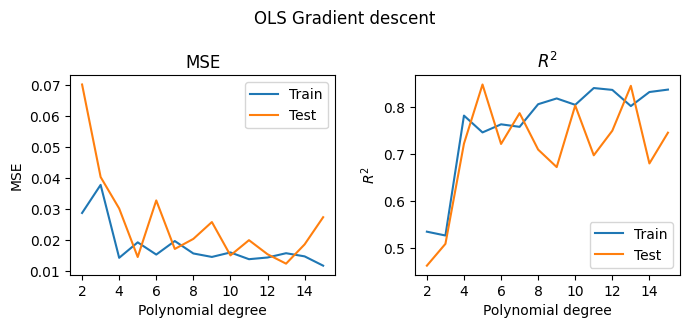

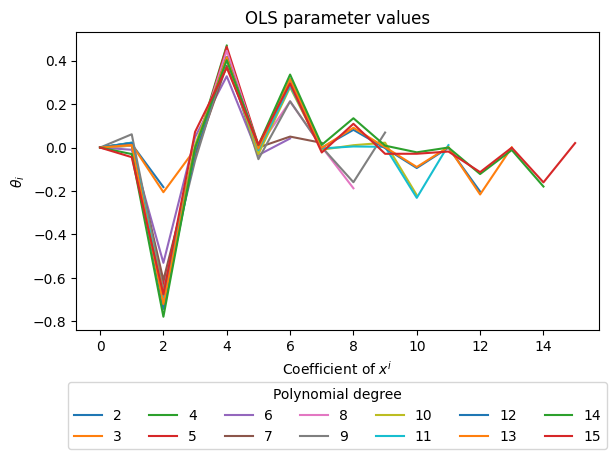

In [3]:
fig, axes = plt.subplots(1, 2, figsize = (7, 3.3))

# Plotting MSE
ax = axes[0]
ax.plot(degrees, mses, label = "Train")
ax.plot(degrees, mses_test, label = "Test")
ax.legend()
ax.set_xticks(degrees[::2])
ax.set_xlabel("Polynomial degree")
ax.set_ylabel("MSE")
ax.set_title("MSE")

# Plotting R^2
ax = axes[1]
ax.plot(degrees, r2s, label = "Train")
ax.plot(degrees, r2s_test, label = "Test")
ax.legend()
ax.set_xticks(degrees[::2])
ax.set_xlabel("Polynomial degree")
ax.set_ylabel(r"$R^2$")
ax.set_title(r"$R^2$")
fig.suptitle("OLS Gradient descent")
fig.tight_layout()

# Plotting beta values
plt.figure()
for degree, beta in zip(degrees, betas):
    plt.plot(range(degree+1), beta, label = str(degree))

plt.title(r"OLS parameter values")
plt.xlabel("Coefficient of $x^i$")
plt.ylabel(r"$\theta_i$")
plt.legend(bbox_to_anchor=(0.5, -0.15), loc='upper center', ncol=len(betas)//2, title="Polynomial degree")
plt.tight_layout()

**Compare with part B**

In [4]:
state_Ridge = np.random.get_state()

learning_rate = 0.05
maxdegree = 15
n_lambdas = 8

lambdas = np.logspace(-7, 0, n_lambdas)
degrees = np.arange(2, maxdegree+1, 1)
mses = []
r2s = []
betas = []

for degree in degrees:
    X = PolynomialFeatures(degree = degree).fit_transform(x)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25)

    # Scaling
    scaler = StandardScaler()
    scaler.fit(X_train)
    X_train_s = scaler.transform(X_train)
    X_test_s = scaler.transform(X_test)
    y_offset = np.mean(y_test)

    # Ridge with gradient descent
    MSE = []
    r2 = []
    for l in lambdas:
        beta = gradient_descent(X_train_s, y_train, Ridge_Gradient, learning_rate, hyperparameter = l).gradient_descent()
        
        predict_test = X_test_s @ beta + y_offset
        MSE.append(mean_squared_error(y_test, predict_test))
        r2.append(r2_score(y_test, predict_test))

        # Storing the betas for the highest degree
        if degree == maxdegree:
            betas.append(beta)
            
    mses.append(MSE)
    r2s.append(r2)

**Plotting**

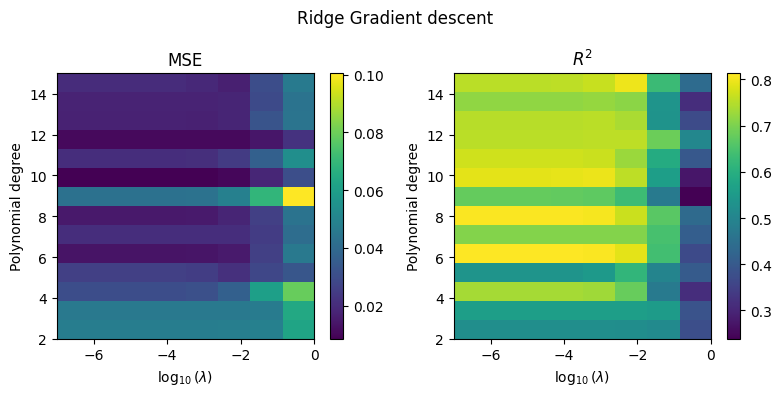

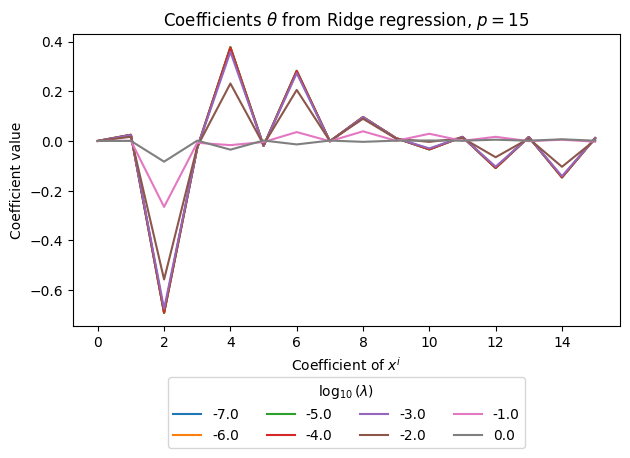

In [5]:
fig, axes = plt.subplots(1, 2, figsize = (8, 4))
fig.suptitle("Ridge Gradient descent")
ax = axes[0]

# Plotting MSE
ax.set_title("MSE")
im = ax.imshow(mses, aspect="auto", extent=(np.log10(lambdas.min()), np.log10(lambdas.max()), degrees.min(), degrees.max()), origin="lower")
ax.set_ylabel("Polynomial degree")
ax.set_xlabel(r"$\log_{10}(\lambda)$")
fig.colorbar(im, ax = ax)

# Plotting R^2
ax = axes[1]
ax.set_title(r"$R^2$")
im = ax.imshow(r2s, aspect="auto", extent=(np.log10(lambdas.min()), np.log10(lambdas.max()), degrees.min(), degrees.max()), origin="lower")
ax.set_xlabel(r"$\log_{10}(\lambda)$")
ax.set_ylabel("Polynomial degree")
fig.colorbar(im, ax = ax)

fig.tight_layout()

# Plotting beta values
plt.figure()
for l, b in zip(lambdas,betas):
    plt.plot(range(maxdegree+1), b.flatten(), label = str(round(np.log10(l),2)))

plt.title(r"Coefficients $\theta$ from Ridge regression, $p=15$")
plt.xlabel(r"Coefficient of $x^i$")
plt.ylabel("Coefficient value")
plt.legend(bbox_to_anchor=(0.5, -0.15), loc='upper center', ncols=len(betas) // 2 + len(betas) % 2, title = r"$\log_{10}(\lambda)$")
plt.tight_layout()

### Role of learning rates on OLS and Ridge

In [6]:
# We have to do the OLS and Ridge separately to use the correct random state for each

learning_rates = [0.05, 0.10, 0.15, 0.17] # Some hand-picked learning rates
l = 1e-4
degree = 12

# Reset random state for OLS
np.random.set_state(state_OLS)

X = PolynomialFeatures(degree = degree).fit_transform(x)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25)

#Scaling
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)
y_offset = np.mean(y_train)

r2s_OLS = []

for learning_rate in learning_rates:
    # Initializing a new solver for each learning rate
    OLS_grad_descent_solver = gradient_descent(X_train_s, y_train, OLS_Gradient, learning_rate=learning_rate)
    
    theta_OLS = OLS_grad_descent_solver.gradient_descent()
    OLS_predictions = X_test_s @ theta_OLS + y_offset
    r2s_OLS.append(r2_score(y_test, OLS_predictions))

# Reset random state for Ridge
np.random.set_state(state_Ridge)

r2s_Ridge = []

for learning_rate in learning_rates:
    # Initializing a new solver for each learning rate
    Ridge_grad_descent_solver = gradient_descent(X_train_s, y_train, Ridge_Gradient, learning_rate=learning_rate, hyperparameter = l)
    
    theta_Ridge = Ridge_grad_descent_solver.gradient_descent()
    ridge_predictions = X_test_s @ theta_Ridge + y_offset
    r2s_Ridge.append(r2_score(y_test, ridge_predictions))

# Printing results in LaTeX table format
print("Learning rate & OLS & Ridge \\\\ \\hline")
for a,b,c in zip(learning_rates,r2s_OLS, r2s_Ridge):
    print(f"{a} & {b:.4E} & {c:.4E} \\\\")

Learning rate & OLS & Ridge \\ \hline
0.05 & 7.7499E-01 & 7.7445E-01 \\
0.1 & 8.0551E-01 & 8.0473E-01 \\
0.15 & 8.1693E-01 & 8.1594E-01 \\
0.17 & -7.9712E+14 & -8.5213E+14 \\
